CNN extracts rich low-level local features quickly and efficiently. But CNNs lack the ability to understand relationships across the entire time window. That’s where the Transformer steps in it globally contextualizes the CNN’s extracted features.

| CNN Part                                  | Transformer Part                           |
| ----------------------------------------- | ------------------------------------------ |
| Excellent for fine-grained local movement | Excellent for sequence-wide understanding  |
| Reduces noise and dimensionality          | Handles complex temporal relationships     |
| Fast & lightweight                        | Powerful, interpretable via attention maps |

### Concept
1. A 1D-CNN layer will first act as a "feature extractor" on the time-series data. It will learn to identify low-level temporal patterns (like sharp movements, oscillations, etc.).
2. The output of the CNN (a new, richer sequence of features) will then be fed into the Transformer Encoder.
3. The Transformer can then apply its global self-attention mechanism to these more meaningful, pre-processed features.


In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import yaml
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import sys
sys.path.append('..')
from src.model import CNNTransformerClassifier 

# --- Configuration ---
RUN_FOLDER = 'C:/CourseWork/Classifying_grip_strategies_ml/outputs/GripTransformer_2025-07-21_13-30-30'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
print(f"Loading results from: {RUN_FOLDER}")


Using device: cuda
Loading results from: C:/CourseWork/Classifying_grip_strategies_ml/outputs/GripTransformer_2025-07-21_13-30-30


In [ ]:
# Load the config file from the run
with open(os.path.join(RUN_FOLDER, 'config.yaml'), 'r') as f:
    config = yaml.safe_load(f)

# Load training metrics
metrics_df = pd.read_csv(os.path.join(RUN_FOLDER, 'training_metrics.csv'))

model_params = config['model']
cnn_transformer_params = config['cnn_transformer']
model = CNNTransformerClassifier(
    input_features=model_params['input_features'],
    num_classes=model_params['num_classes'],
    seq_length=model_params['sequence_length'],
    cnn_out_channels=cnn_transformer_params['cnn_out_channels'],
    d_model=cnn_transformer_params['d_model'],
    nhead=cnn_transformer_params['nhead'],
    num_encoder_layers=cnn_transformer_params['num_encoder_layers'],
    dim_feedforward=cnn_transformer_params['dim_feedforward'],
    dropout=cnn_transformer_params['dropout']
)

# Load the saved model weights
model_path = os.path.join(RUN_FOLDER, 'best_model.pth')
model.load_state_dict(torch.load(model_path, map_location=DEVICE))
model.to(DEVICE)
model.eval()
print("CNN-Transformer Model loaded successfully.")

# Load the test data and label mapping (this part is the same)
processed_data_path = 'C:/CourseWork/Classifying_grip_strategies_ml/data/03_processed_dl/' 
X_test = np.load(os.path.join(processed_data_path, 'X_test.npy'))
y_test = np.load(os.path.join(processed_data_path, 'y_test.npy'))

raw_df_path = 'C:/CourseWork/Classifying_grip_strategies_ml/data/02_processed/GripFormer_preprocessed_dataset.csv'
with open(raw_df_path, 'r') as f:
    for i, line in enumerate(f):
        if line.strip().startswith('unique_sequence_id'):
            header_row = i
            break
raw_df = pd.read_csv(raw_df_path, skiprows=header_row)
raw_df.columns = [col.strip() for col in raw_df.columns]
label_map = raw_df[['label_encoded', 'label']].drop_duplicates().sort_values('label_encoded').set_index('label_encoded')['label']
class_names = label_map.tolist()
print("\nTest data and label mapping loaded.")

CNN-Transformer Model loaded successfully.

Test data and label mapping loaded.


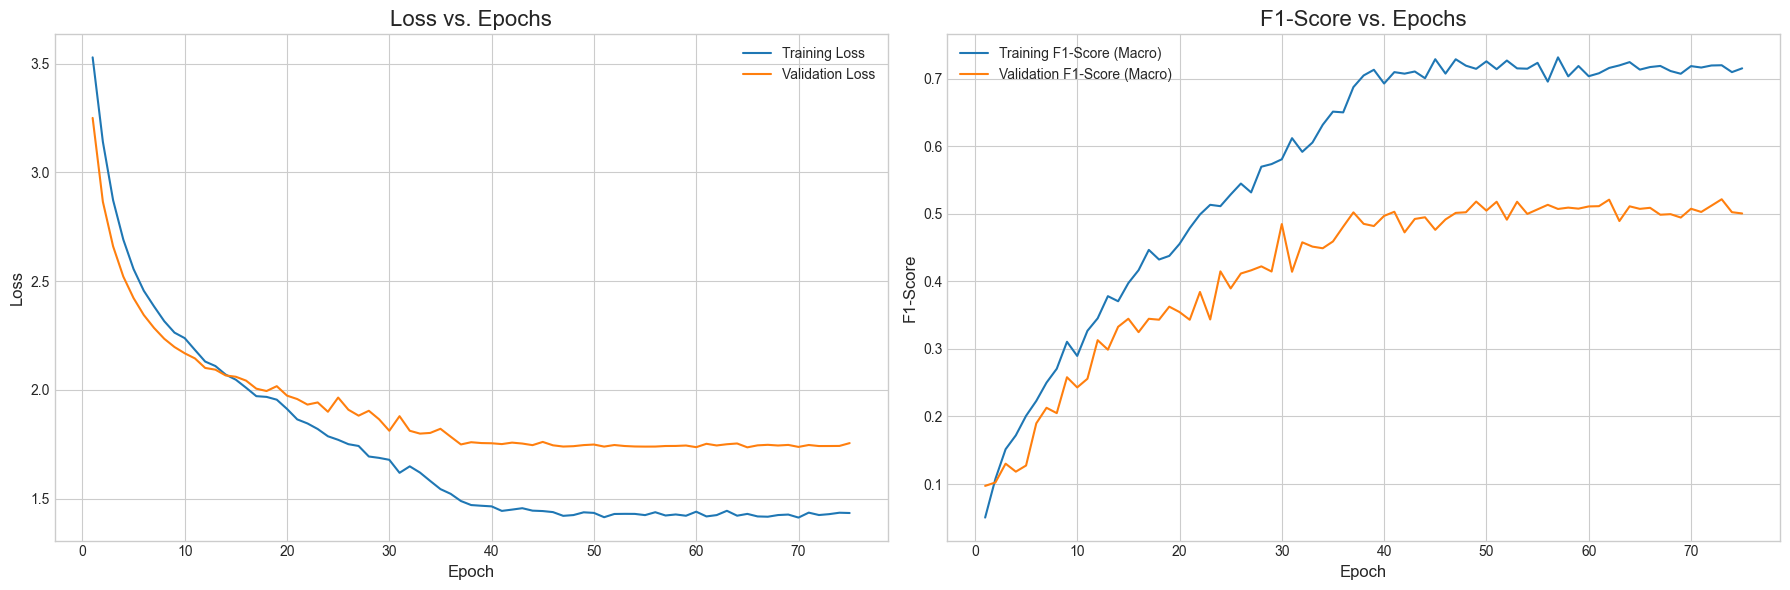

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plotting Loss
ax1.plot(metrics_df['epoch'], metrics_df['train_loss'], label='Training Loss')
ax1.plot(metrics_df['epoch'], metrics_df['val_loss'], label='Validation Loss')
ax1.set_title('Loss vs. Epochs', fontsize=16)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend()

# Plotting F1-Score
ax2.plot(metrics_df['epoch'], metrics_df['train_f1'], label='Training F1-Score (Macro)')
ax2.plot(metrics_df['epoch'], metrics_df['val_f1'], label='Validation F1-Score (Macro)')
ax2.set_title('F1-Score vs. Epochs', fontsize=16)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('F1-Score', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()

In [4]:
test_dataset = TensorDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())
test_loader = DataLoader(test_dataset, batch_size=config["training"]["batch_size"])

y_pred_list = []
y_true_list = []

with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(features)
        preds = torch.argmax(outputs, dim=1)

        y_pred_list.extend(preds.cpu().numpy())
        y_true_list.extend(labels.cpu().numpy())

# Gen and print the classification report
print("Classificaiton Report on Test Set")
report = classification_report(y_true_list, y_pred_list, target_names=class_names, zero_division=0)
print(report)

# Precision: Of all samples predicted as this class, how many were correct? (True Positives / Predicted Positives)

# Recall: Of all actual samples belonging to this class, how many did the model correctly identify? (True Positives / Actual Positives)

# F1-score: Harmonic mean of precision and recall; balances the two to give a single performance measure.

# Support: The number of true samples in that class within the test set.

Classificaiton Report on Test Set
                                              precision    recall  f1-score   support

                       aiming_bino_black_one       0.20      0.33      0.25         6
                     aiming_bino_black_three       0.25      0.25      0.25        12
                       aiming_bino_black_two       0.00      0.00      0.00         9
                        aiming_bino_wood_one       0.25      0.10      0.14        10
                      aiming_bino_wood_three       0.42      0.45      0.43        11
                        aiming_bino_wood_two       0.00      0.00      0.00         8
                      aiming_clear_black_one       0.43      0.50      0.46         6
                    aiming_clear_black_three       0.35      0.67      0.46         9
                      aiming_clear_black_two       0.50      0.62      0.56         8
                       aiming_clear_wood_one       0.43      0.46      0.44        13
                   


--- Confusion Matrix ---


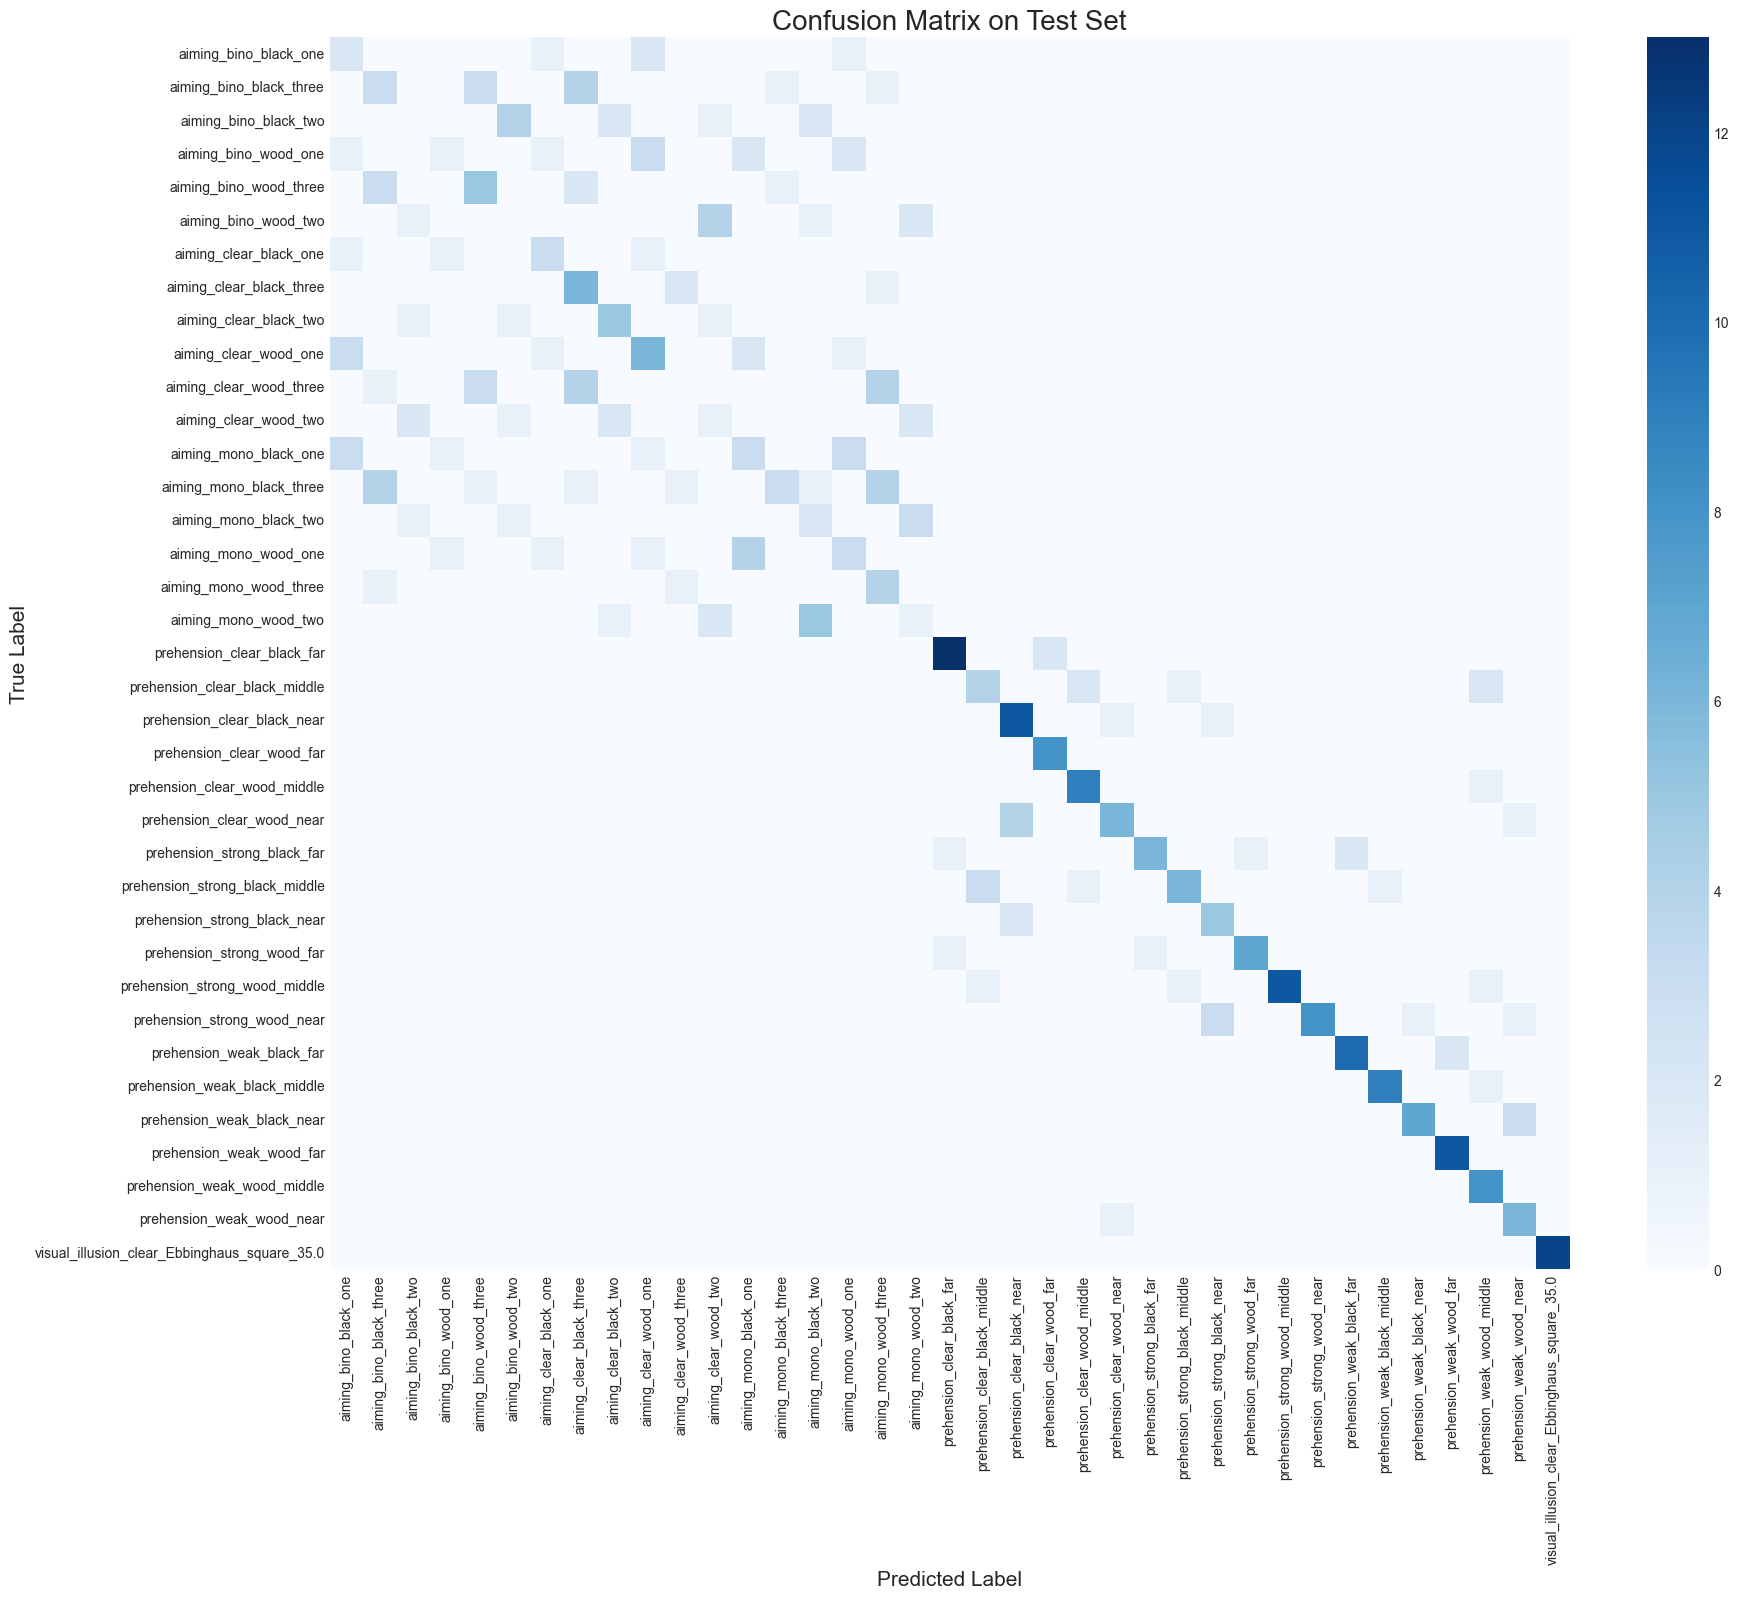

In [5]:
# Gen and plot the confusion matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true_list, y_pred_list)
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix on Test Set', fontsize=20)
plt.xlabel('Predicted Label', fontsize=15)
plt.ylabel('True Label', fontsize=15)
plt.show()

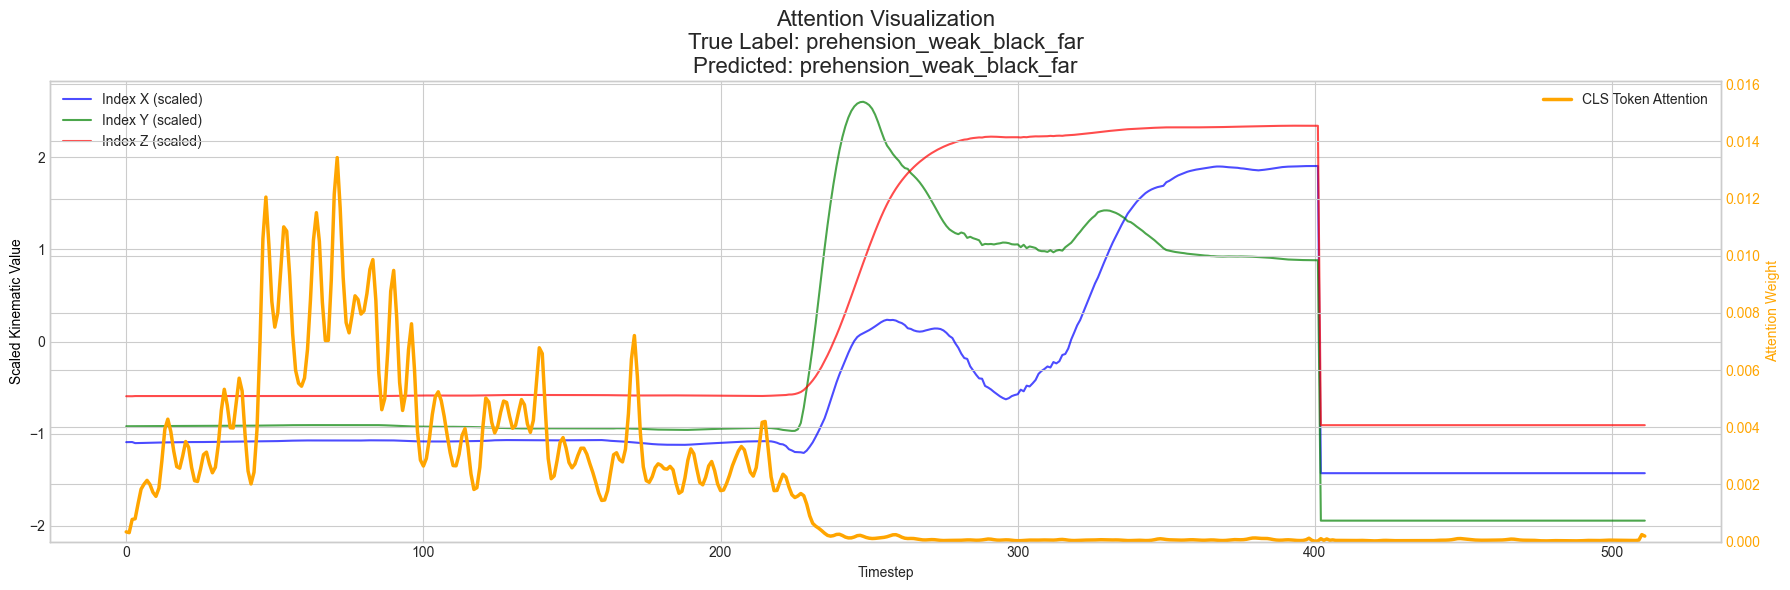

In [11]:
sample_idx = 0
single_sequence = torch.from_numpy(X_test[sample_idx]).float().unsqueeze(0).to(DEVICE)
true_label_idx = y_test[sample_idx]
true_label_name = class_names[true_label_idx]

logits, attention_weights = model(single_sequence, return_attention=True)
pred_label_idx = torch.argmax(logits, dim=1).item()
pred_label_name = class_names[pred_label_idx]

cls_attention = attention_weights[0, 0, 1:].detach().cpu().numpy()
fig, ax1 = plt.subplots(figsize=(18, 6))

timesteps = np.arange(X_test.shape[1])
ax1.plot(timesteps, X_test[sample_idx, :, 0], color='blue', label='Index X (scaled)', alpha=0.7)
ax1.plot(timesteps, X_test[sample_idx, :, 1], color='green', label='Index Y (scaled)', alpha=0.7)
ax1.plot(timesteps, X_test[sample_idx, :, 2], color='red', label='Index Z (scaled)', alpha=0.7)
ax1.set_xlabel('Timestep')
ax1.set_ylabel('Scaled Kinematic Value', color='black')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(timesteps, cls_attention, color='orange', linewidth=2.5, label='CLS Token Attention')
ax2.set_ylabel('Attention Weight', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.set_ylim(0, np.max(cls_attention) * 1.2) 
ax2.legend(loc='upper right')

plt.title(f'Attention Visualization\nTrue Label: {true_label_name}\nPredicted: {pred_label_name}', fontsize=16)
fig.tight_layout()
plt.show()

The first model's analysis
* It paid low attention at the beginning.
* It had a small peak when the motion started.
* It became very active and "spiky" at the end of the motion focusing on the final hand stabilization.

Analysis of the NEW CNN-Transformer Attention Plot:

* Attention has shifted from the end to the beginning.
* Early, Decisive Focus (0-150 timesteps): The attention is now extremely high during the initial "rest" phase of the movement. It's a flurry of intense activity before the hand has even started moving significantly (which begins around timestep 200).
* Diminished Importance of the End (post-400 timesteps): After the initial phase, the attention drops to almost zero for the rest of the sequence, including the final hold phase that the previous model found so important.

What does this mean?

1. The CNN as a "Pattern Spotter": The initial 1D-CNN layers are acting as powerful, learned feature extractors. They are scanning the raw kinematic data and identifying subtle, low-level patterns. For instance, they might be learning to spot "micro-tremors," "postural adjustments," or tiny changes in velocity that are invisible to the naked eye but are characteristic of planning a specific grasp.
2. The Transformer as a "Concept Aggregator": The Transformer no longer needs to analyze the entire raw sequence to figure out what's going on. It receives the highly informative, pre-processed features from the CNN. The attention plot shows that the Transformer has learned that all the information it needs to make a decision is contained within the initial patterns detected by the CNN during the planning phase.
3. A More "Human" Strategy? We could argue this is a more sophisticated and human-like strategy. Before you even begin to reach for an object, your brain has already planned the entire motion and pre-shaped your hand. The model appears to have discovered this. It's essentially saying, "Based on the subtle patterns I see in the first 150 timesteps, I am 99% sure this is going to be a prehension_weak_black_far grasp, and I don't need to pay much attention to the rest of the execution."